## STEP 1: IMPORT LIBRARY. ##

In [1]:
!pip install torch


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install torchvision


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix

## STEP 2: LOAD DATA. ##

In [2]:
#-- Input training directory. --#
train_dir = "../Datasets/Train/Numbers"
file_paths = sorted(glob.glob(os.path.join(train_dir, "*.csv")))
#-- Check directory folder. --#
if not file_paths:
    print(f"Cannot find any CSV in the folder: {file_paths}")
else:
    df_list = []
    #-- For loop. --#
    for file in file_paths:
        print(f"Reading file: {file}")
        slice_df = pd.read_csv(file, encoding="utf-8")
        df_list.append(slice_df)

    train_df = pd.concat(df_list, ignore_index=True)

    print("Results:")
    print("Shape of the DataFrame:", train_df.shape)
    print(f"Number of rows: {train_df.shape[0]}")
    print(f"Number of columns: {train_df.shape[1]}")

Reading file: ../Datasets/Train/Numbers\mnist_train_1.csv
Reading file: ../Datasets/Train/Numbers\mnist_train_2.csv
Reading file: ../Datasets/Train/Numbers\mnist_train_3.csv
Reading file: ../Datasets/Train/Numbers\mnist_train_4.csv
Reading file: ../Datasets/Train/Numbers\mnist_train_5.csv
Reading file: ../Datasets/Train/Numbers\mnist_train_6.csv
Results:
Shape of the DataFrame: (60000, 785)
Number of rows: 60000
Number of columns: 785


## STEP 3: Show images of data. ##

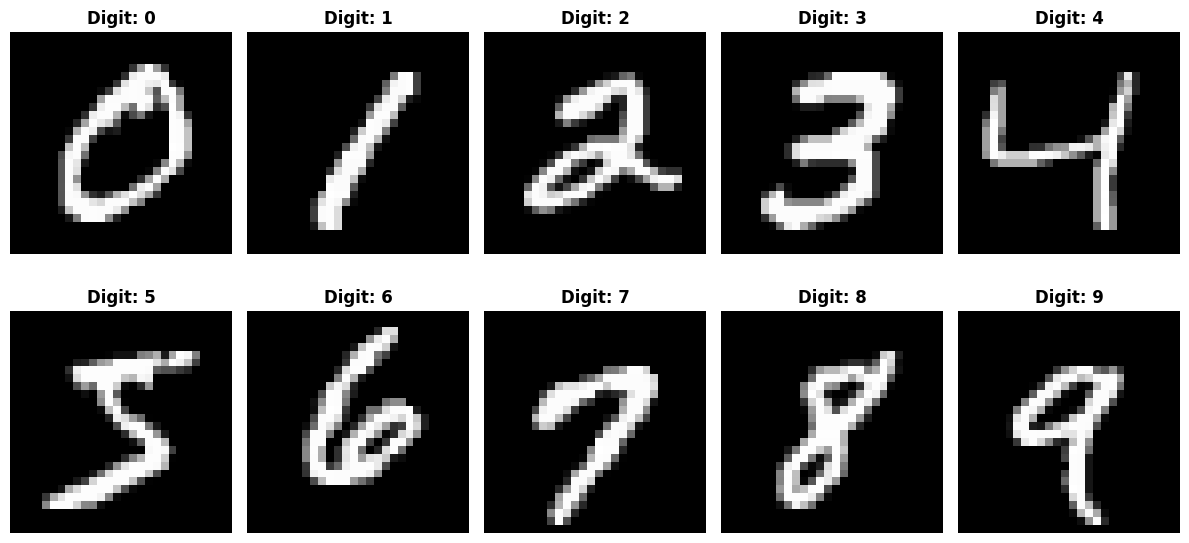

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for digit in range(10):
    digit_row = train_df[train_df["label"] == digit].iloc[0]
    pixel_features = digit_row.drop("label").values
    image_matrix = pixel_features.reshape(28, 28)

    axes[digit].imshow(image_matrix, cmap="gray")
    axes[digit].set_title(f"Digit: {digit}", fontsize=12, fontweight="bold")
    axes[digit].axis("off") 

plt.tight_layout()
plt.show()

## STEP 4: Figures. ##

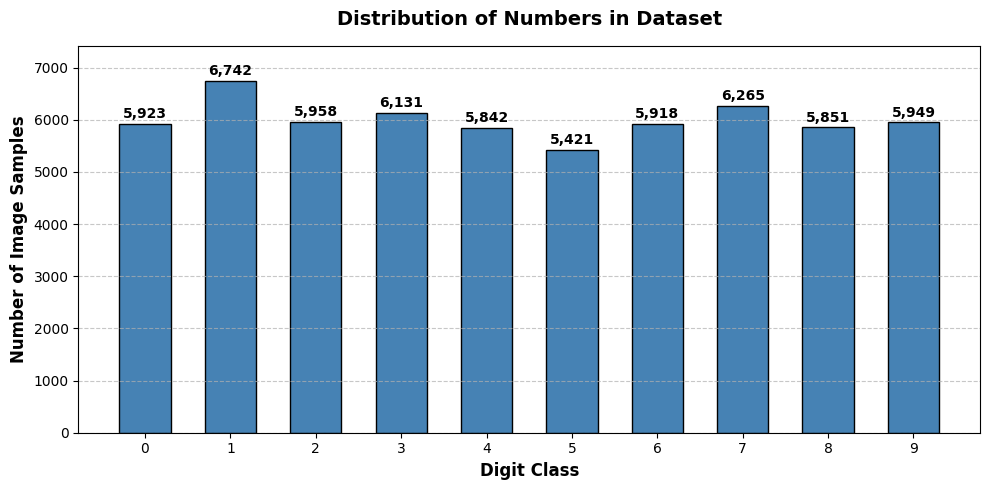

In [4]:
#-- 1. Compute the count of each digit class from loaded train_df. --#
digit_counts = train_df["label"].value_counts().sort_index()

#-- 2. Setup the figure layout. --#
plt.figure(figsize=(10, 5))

#-- 3. Create the bar plot using standard Matplotlib. --#
bars = plt.bar(
    digit_counts.index, 
    digit_counts.values, 
    color="#4682B4", 
    edgecolor="black", 
    width=0.6
)

#-- 4. Annotate total counts on top of each bar. --#
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 50,  # Place text slightly above the bar peak
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

#-- 5. Add professional titles and labels for your project report documentation. --#
plt.title("Distribution of Numbers in Dataset", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Digit Class", fontsize=12, fontweight="bold")
plt.ylabel("Number of Image Samples", fontsize=12, fontweight="bold")
plt.xticks(range(10))  

#-- Add a subtle grid on the background (y-axis only). --#
plt.grid(axis='y', linestyle='--', alpha=0.7)

#-- Set a safety margin at the top of the plot area. --#
plt.ylim(0, max(digit_counts.values) * 1.1)
plt.tight_layout()
plt.show()

In [5]:
target_dir = "../figures"

# 1. Check if target folder exists, then save the figure strictly with 0 rebuilds
if os.path.exists(target_dir):
    save_path = os.path.join(target_dir, "Digit_distribution.png")
    
    # Save the existing active figure directly from memory
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Success: Active figure exported directly to -> {save_path}")
else:
    print(f"Error: Folder '{target_dir}' not found.")

Success: Active figure exported directly to -> ../figures\Digit_distribution.png


<Figure size 640x480 with 0 Axes>

## STEP 5: Build Convolutional Layer. ##

# Step 5.1: Kernel/Filter Layer. 

In [7]:
### STep 3.1: Build Kernel/Filter Layer. ###
print("Filter/Kernel Layer generating.....")

filter_layer = nn.Conv2d(
    in_channels = 1,
    out_channels = 32,
    kernel_size = 3,
    stride = 1,
    padding = 1
)

weights = filter_layer.weight.data
biases = filter_layer.bias.data

print("Filter/Kernel Layer generated successfully.")

Filter/Kernel Layer generating.....
Filter/Kernel Layer generated successfully.


In [8]:
#-- Load the first raw CSV file data slice. --#
raw_df = pd.read_csv(file_paths[0], encoding="utf-8")
first_sample = raw_df.iloc[0]

#-- Extract label and normalize 784 pixels to [0.0, 1.0] range. --#
sample_label = int(first_sample["label"])
pixels = first_sample.drop("label").values.astype("float32") / 255.0

#-- Reshape flat matrix to 4D Image tensor: (Batch, Channels, Height, Width). --#
input_tensor = torch.tensor(pixels).view(1, 1, 28, 28)

In [9]:
print(f"--- Visualize the Dataframe: [{sample_label}] ---")
sample_df_view = first_sample.to_frame().T
sample_df_view.iloc[:, :11]

--- Visualize the Dataframe: [5] ---


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10
0,5,0,0,0,0,0,0,0,0,0,0


In [10]:
print("Extracting unique labels from the dataset...")

batch_pixels = []
for digit in range(10):
    digit_row = train_df[train_df["label"] == digit].iloc[0]
    pixel_features = digit_row.drop("label").values.astype("float32") / 255.0
    batch_pixels.append(pixel_features)
batch_tensor = torch.tensor(batch_pixels).view(10, 1, 28, 28)

print(f"Multi-class data compilation complete!")
print(f"Unified Input Batch Tensor Shape: {batch_tensor.shape} (10 Digits, 1 Channel, 28x28 Pixels)")

Extracting unique labels from the dataset...
Multi-class data compilation complete!
Unified Input Batch Tensor Shape: torch.Size([10, 1, 28, 28]) (10 Digits, 1 Channel, 28x28 Pixels)


C:\Users\DELL\AppData\Local\Temp\ipykernel_404\1335191027.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  batch_tensor = torch.tensor(batch_pixels).view(10, 1, 28, 28)


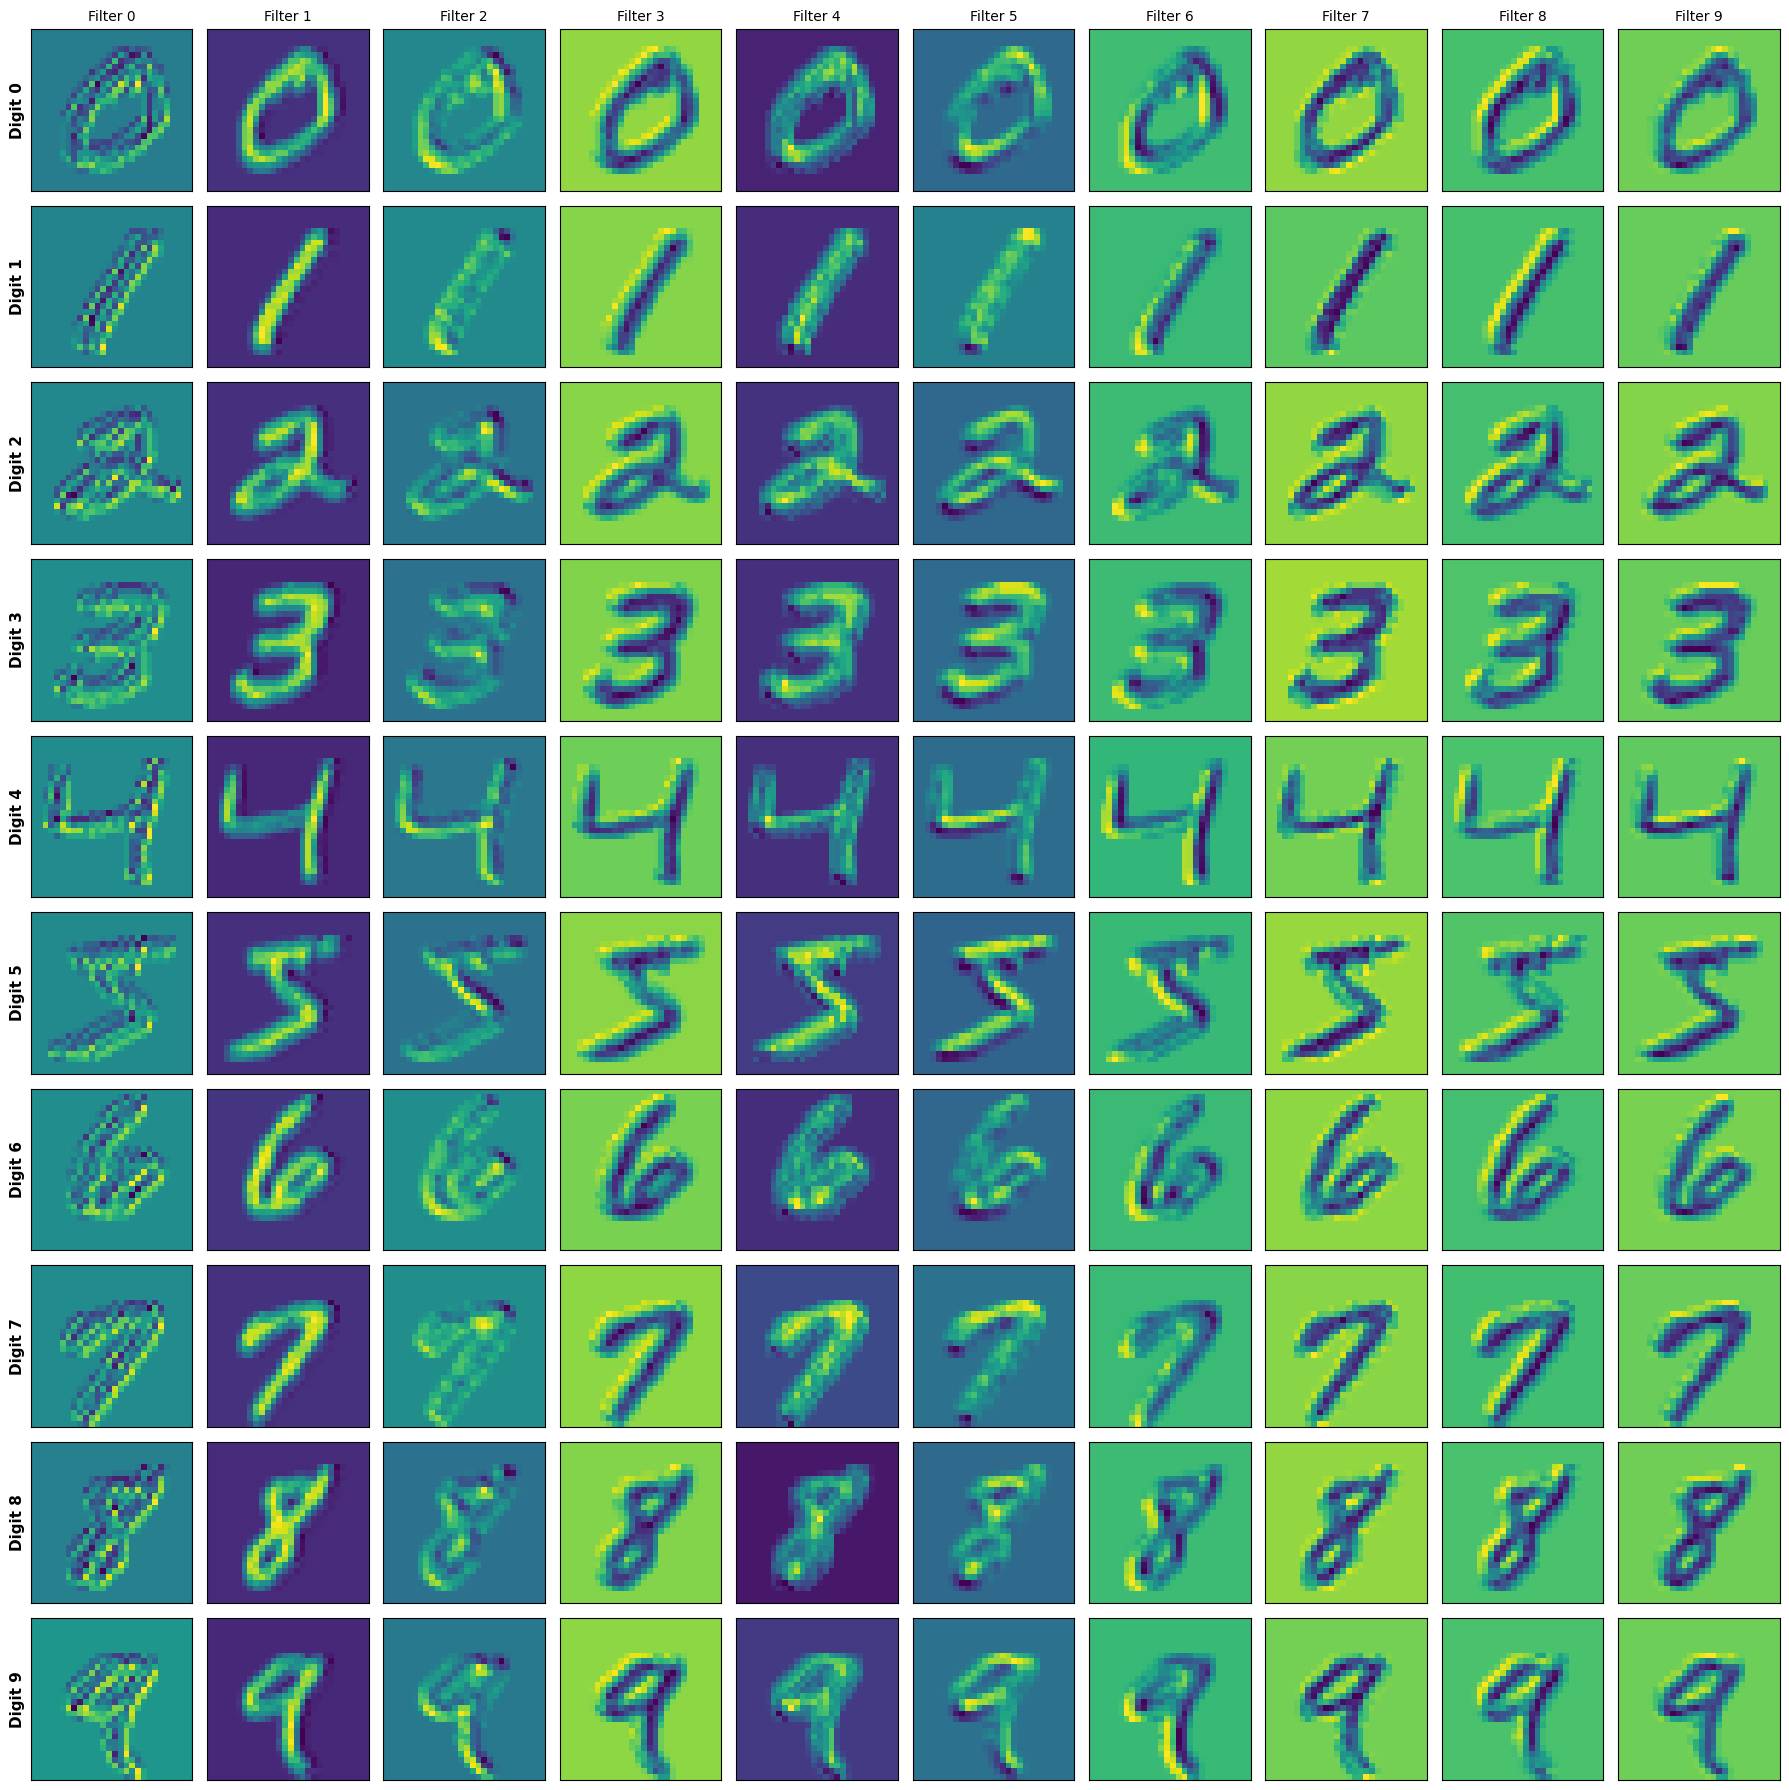

In [11]:
#-- Forward pass the entire batch through filter_layer (No gradients calculation). --#
with torch.no_grad():
    #-- Output matrix shape will be (10, 32, 28, 28) -> 10 digits, 32 filters each. --#
    batch_feature_maps = filter_layer(batch_tensor)

#-- Initialize a crisp 10x10 subplot layout (Rows: Digits 0-9, Columns: Filters 0-9). --#
fig, axes = plt.subplots(10, 10, figsize=(18, 18))

for digit in range(10):
    for filter_idx in range(10):
        #-- Extract the specific 2D matrix channel for current digit and filter. --#
        f_map_numpy = batch_feature_maps[digit, filter_idx].numpy()
        
        #-- Target the exact grid coordinate cell. --#
        ax = axes[digit, filter_idx]
        ax.imshow(f_map_numpy, cmap="viridis")
        
        #-- Set clean outer border descriptions for report documentation prose. --#
        if filter_idx == 0:
            ax.set_ylabel(f"Digit {digit}", fontsize=11, fontweight="bold")
        if digit == 0:
            ax.set_title(f"Filter {filter_idx}", fontsize=10)
            
        ax.set_xticks([])
        ax.set_yticks([])

#-- Place a professional main header over the grid. --#
plt.tight_layout()

In [12]:
target_dir = "../Figures/"

if os.path.exists(target_dir):
    save_path = os.path.join(target_dir, "Digit_feature_maps_matrix.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Success: Comprehensive 10x10 matrix exported to -> {save_path}")
else:
    print(f"Warning: Target folder '{target_dir}' not found. File export skipped.")

# 3. Clean render display
plt.show()

Success: Comprehensive 10x10 matrix exported to -> ../Figures/Digit_feature_maps_matrix.png


<Figure size 640x480 with 0 Axes>

# Step 5.2: Batch Normalization Layer. #

In [29]:
#-- Step 3.2: Initialize Batch Normalization Layer. --#
print("Batch Normalization Layer Initializing.....")

batch_norm_layer = nn.BatchNorm2d(num_features=32)
batch_norm_layer.eval()

print("Batch Normalization Layer Overall Information.")
print(f"Layer Type: {type(batch_norm_layer).__name__}")
print(f"Input Feature Channels (C): {batch_norm_layer.num_features}")
print(f"Learnable Parameters: {batch_norm_layer.num_features * 2} (Gamma and Beta for each channel)")
print(f"Non-learnable Parameters: {batch_norm_layer.num_features * 2} (Running Mean and Variance for each channel)")

Batch Normalization Layer Initializing.....
Batch Normalization Layer Overall Information.
Layer Type: BatchNorm2d
Input Feature Channels (C): 32
Learnable Parameters: 64 (Gamma and Beta for each channel)
Non-learnable Parameters: 64 (Running Mean and Variance for each channel)


In [30]:
print("Visualize Initial Batch Normalization Parameters. ---")
#-- Extract the raw vector data from PyTorch layer parameters. --#
bn_weights = batch_norm_layer.weight.data.numpy()
bn_biases = batch_norm_layer.bias.data.numpy()
#-- Create a structured dictionary focusing on the first 10 filter channels. --#
param_dict = {
    "Channel Index": [f"Filter {i}" for i in range(10)],
    "Weight (Gamma - γ)": bn_weights[:10],
    "Bias (Beta - β)": bn_biases[:10]
}
#-- Convert to a crisp DataFrame for rich visualization representation. --#
bn_param_df = pd.DataFrame(param_dict).set_index("Channel Index").T
#-- Display using the native Jupyter Notebook table renderer. --#
bn_param_df

Visualize Initial Batch Normalization Parameters. ---


Channel Index,Filter 0,Filter 1,Filter 2,Filter 3,Filter 4,Filter 5,Filter 6,Filter 7,Filter 8,Filter 9
Weight (Gamma - γ),1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Bias (Beta - β),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
print("Normalize feature map activations across the data batch....")
#-- Execute the forward pass safely without updating history gradients tracks. --#
with torch.no_grad():
    #-- Input shape: (10, 32, 28, 28) -> Output shape remains: (10, 32, 28, 28). --#
    bn_feature_maps = batch_norm_layer(batch_feature_maps)

print("Feature maps normalized successfully.")
print(f"Normalized Maps Batch Shape: {bn_feature_maps.shape}")

Normalize feature map activations across the data batch....
Feature maps normalized successfully.
Normalized Maps Batch Shape: torch.Size([10, 32, 28, 28])


Plotting pixel distribution changes for output...


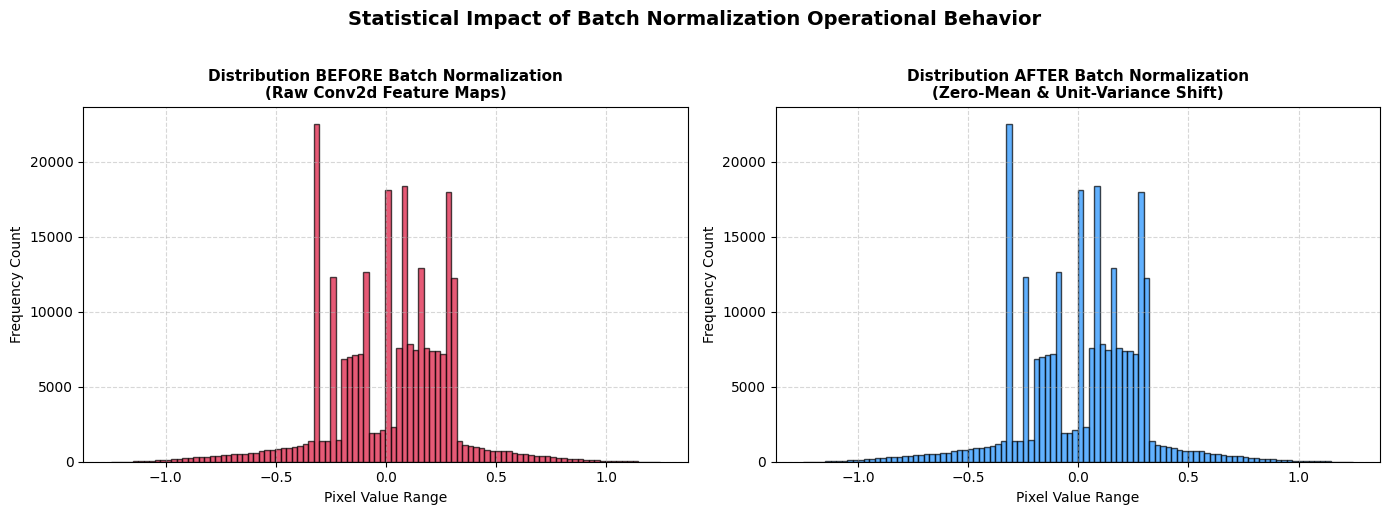

In [32]:
print("Plotting pixel distribution changes for output...")

# Flatten the tensors to 1D arrays to compute distribution statistics
raw_conv_pixels = batch_feature_maps.numpy().flatten()
bn_processed_pixels = bn_feature_maps.numpy().flatten()

# Setup a clean 1x2 subplot structure for side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Distribution Before BatchNorm (Output of Conv2d)
ax1.hist(raw_conv_pixels, bins=100, color="crimson", alpha=0.7, edgecolor="black")
ax1.set_title("Distribution BEFORE Batch Normalization\n(Raw Conv2d Feature Maps)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Pixel Value Range")
ax1.set_ylabel("Frequency Count")
ax1.grid(True, linestyle="--", alpha=0.5)

# 2. Plot Distribution AFTER BatchNorm
ax2.hist(bn_processed_pixels, bins=100, color="dodgerblue", alpha=0.7, edgecolor="black")
ax2.set_title("Distribution AFTER Batch Normalization\n(Zero-Mean & Unit-Variance Shift)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Pixel Value Range")
ax2.set_ylabel("Frequency Count")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Statistical Impact of Batch Normalization Operational Behavior", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()

# Render cleanly inside notebook
plt.show()

In [33]:
target_dir = "../Figures"

if os.path.exists(target_dir):
    save_path = os.path.join(target_dir, "Statistical_Impact_of_Batch_Normalization.png")
    
    # Target the active histogram figure context and save with high density layout
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Success: Distribution histogram exported directly to -> {save_path}")
else:
    print(f"Warning: Target folder '{target_dir}' not detected. File export skipped.")

Success: Distribution histogram exported directly to -> ../Figures\Statistical_Impact_of_Batch_Normalization.png


Rendering 10x10 Batch Normalization visualization matrix grid...


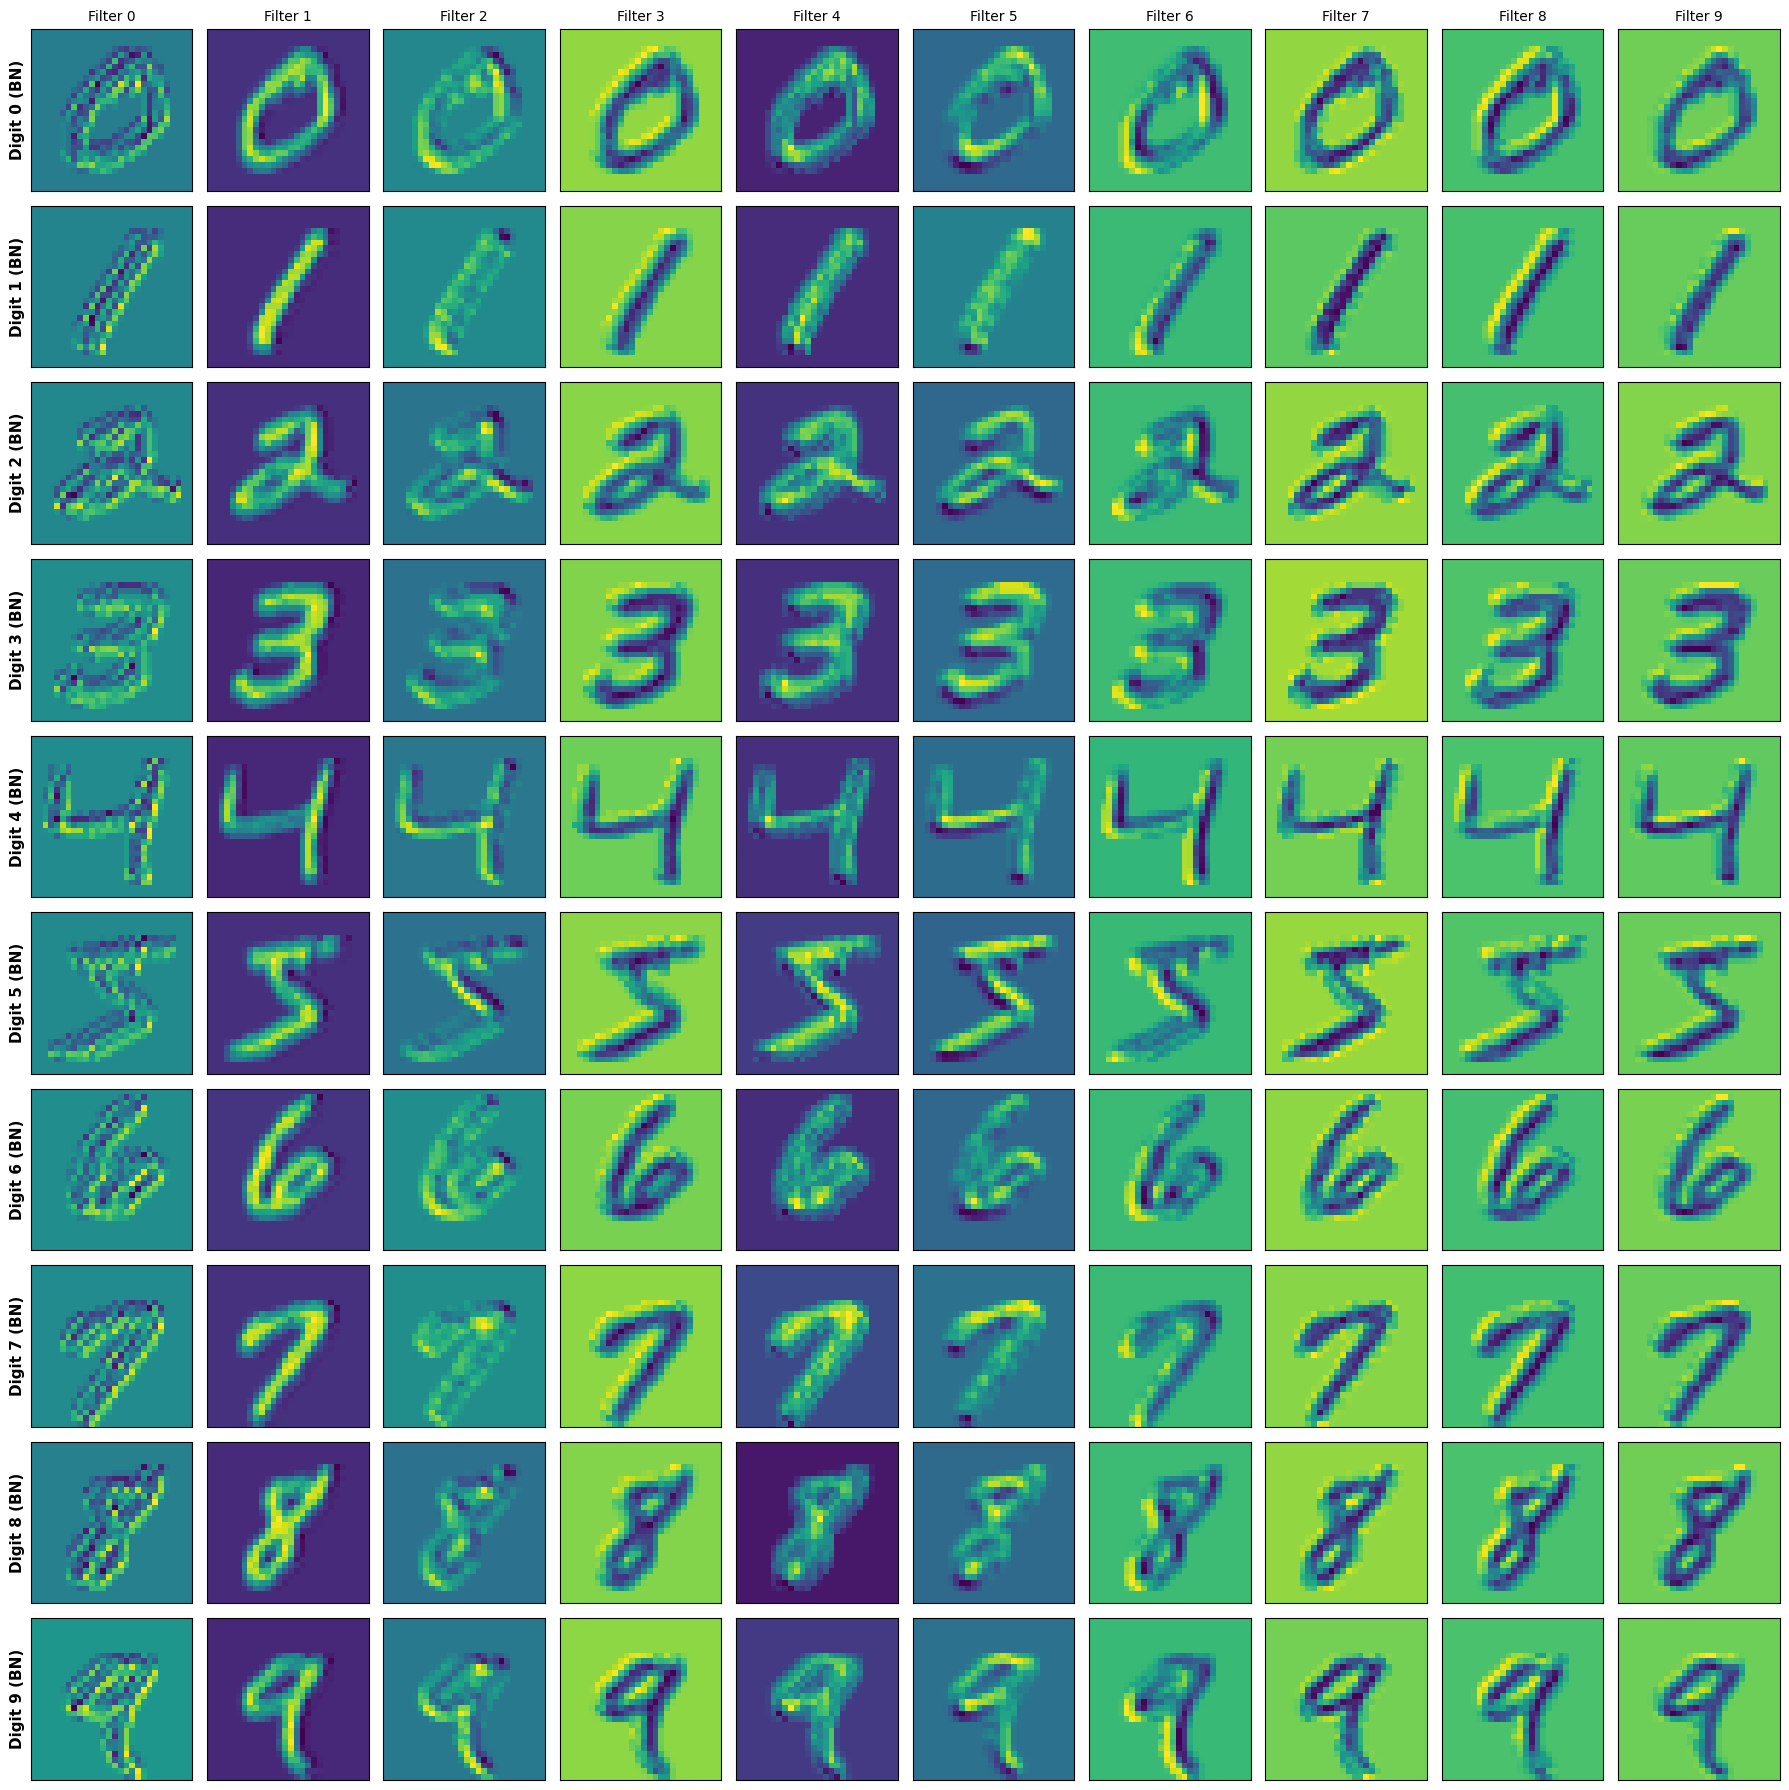

In [34]:
print("Rendering 10x10 Batch Normalization visualization matrix grid...")

#-- Initialize a clean 10x10 canvas (Rows: Digits 0-9, Columns: Filters 0-9). --#
fig, axes = plt.subplots(10, 10, figsize=(18, 18))
#-- Map coordinates to plot each digit row and filter column channel. --#
for digit in range(10):
    for filter_idx in range(10):
        #-- Extract individual 2D slice processed by BatchNorm. --#
        bn_map_numpy = bn_feature_maps[digit, filter_idx].numpy()
        ax = axes[digit, filter_idx]
        ax.imshow(bn_map_numpy, cmap="viridis")
        #-- Add outer typography layouts for professional prose integration. --#
        if filter_idx == 0:
            ax.set_ylabel(f"Digit {digit} (BN)", fontsize=11, fontweight="bold")
        if digit == 0:
            ax.set_title(f"Filter {filter_idx}", fontsize=10)
        #-- Hide internal coordinate metrics for a cleaner publication style. --#
        ax.set_xticks([])
        ax.set_yticks([])

#-- Apply an elegant main title across the entire asset matrix. --#
plt.tight_layout()

## Step 5.3: ReLU Activation Layer. ##

In [35]:
#-- Step 5.3: ReLU. --#
print("ReLU Activation Layer Initializing.....")
#-- Initialize the ReLU activation layer. --#
relu_layer = nn.ReLU()

total_pixels = bn_feature_maps.numel()
negative_pixels = torch.sum(bn_feature_maps < 0).item()
negative_percentage = (negative_pixels / total_pixels) * 100

max_val = torch.max(bn_feature_maps).item()
min_val = torch.min(bn_feature_maps).item()

#--Print crucial parameters. --#
print("ReLU Activation Layer Overall Information.")
print(f"Layer Type: {type(relu_layer).__name__}")
print(f"Total Pixels in Batch: {total_pixels}")
print(f"Negative Pixels Count: {negative_pixels} ({negative_percentage:.2f}%)")
print(f"Pixel Value Range Before ReLU: [{min_val:.4f}, {max_val:.4f}]")


ReLU Activation Layer Initializing.....
ReLU Activation Layer Overall Information.
Layer Type: ReLU
Total Pixels in Batch: 250880
Negative Pixels Count: 102462 (40.84%)
Pixel Value Range Before ReLU: [-1.2509, 1.2454]


In [36]:
print("Applying ReLU activation function to the batch of feature maps...")
relu_feature_maps = relu_layer(bn_feature_maps)
print("ReLU activation applied successfully.")
print(f"Feature maps shape after ReLU: {relu_feature_maps.shape}")

Applying ReLU activation function to the batch of feature maps...
ReLU activation applied successfully.
Feature maps shape after ReLU: torch.Size([10, 32, 28, 28])


Plotting pixel distribution changes for ReLU output...


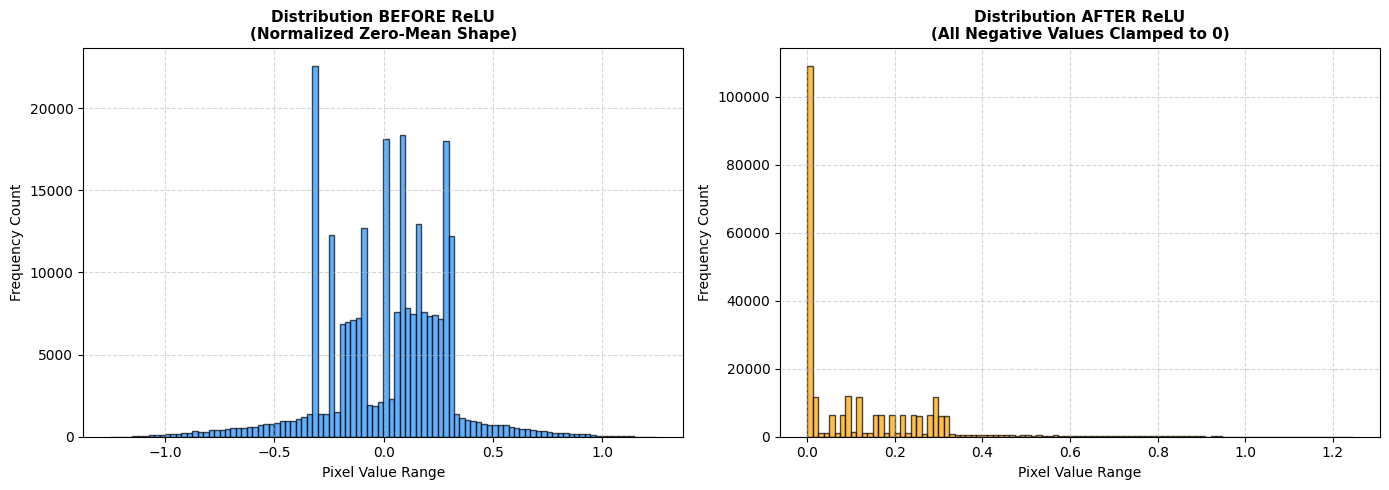

In [37]:
print("Plotting pixel distribution changes for ReLU output...")
#-- Flatten the tensors to 1D arrays to capture the activation shift. --#
bn_pixels_before_relu = bn_feature_maps.numpy().flatten()
relu_pixels_after_relu = relu_feature_maps.numpy().flatten()
#-- Setup a clean 1x2 subplot structure for side-by-side comparison. --@
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#-- Plot Distribution Before ReLU (Output of BatchNorm). --#
ax1.hist(bn_pixels_before_relu, bins=100, color="dodgerblue", alpha=0.7, edgecolor="black")
ax1.set_title("Distribution BEFORE ReLU\n(Normalized Zero-Mean Shape)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Pixel Value Range")
ax1.set_ylabel("Frequency Count")
ax1.grid(True, linestyle="--", alpha=0.5)
#-- Plot Distribution AFTER ReLU. --#
ax2.hist(relu_pixels_after_relu, bins=100, color="orange", alpha=0.7, edgecolor="black")
ax2.set_title("Distribution AFTER ReLU\n(All Negative Values Clamped to 0)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Pixel Value Range")
ax2.set_ylabel("Frequency Count")
ax2.grid(True, linestyle="--", alpha=0.5)
#-- Show figure. --#
plt.tight_layout()
plt.show()

In [38]:
target_dir = "../Figures"

if os.path.exists(target_dir):
    save_path = os.path.join(target_dir, "Statistical_Impact_of_ReLU_Activation_Distribution_Comparison.png")
    
    # Export the active figure canvas with clean document margins
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Success: ReLU distribution histogram exported directly to -> {save_path}")
else:
    print(f"Warning: Target folder '{target_dir}' not detected. File export skipped.")

Success: ReLU distribution histogram exported directly to -> ../Figures\Statistical_Impact_of_ReLU_Activation_Distribution_Comparison.png


Rendering 10x10 ReLU activated matrix grid...


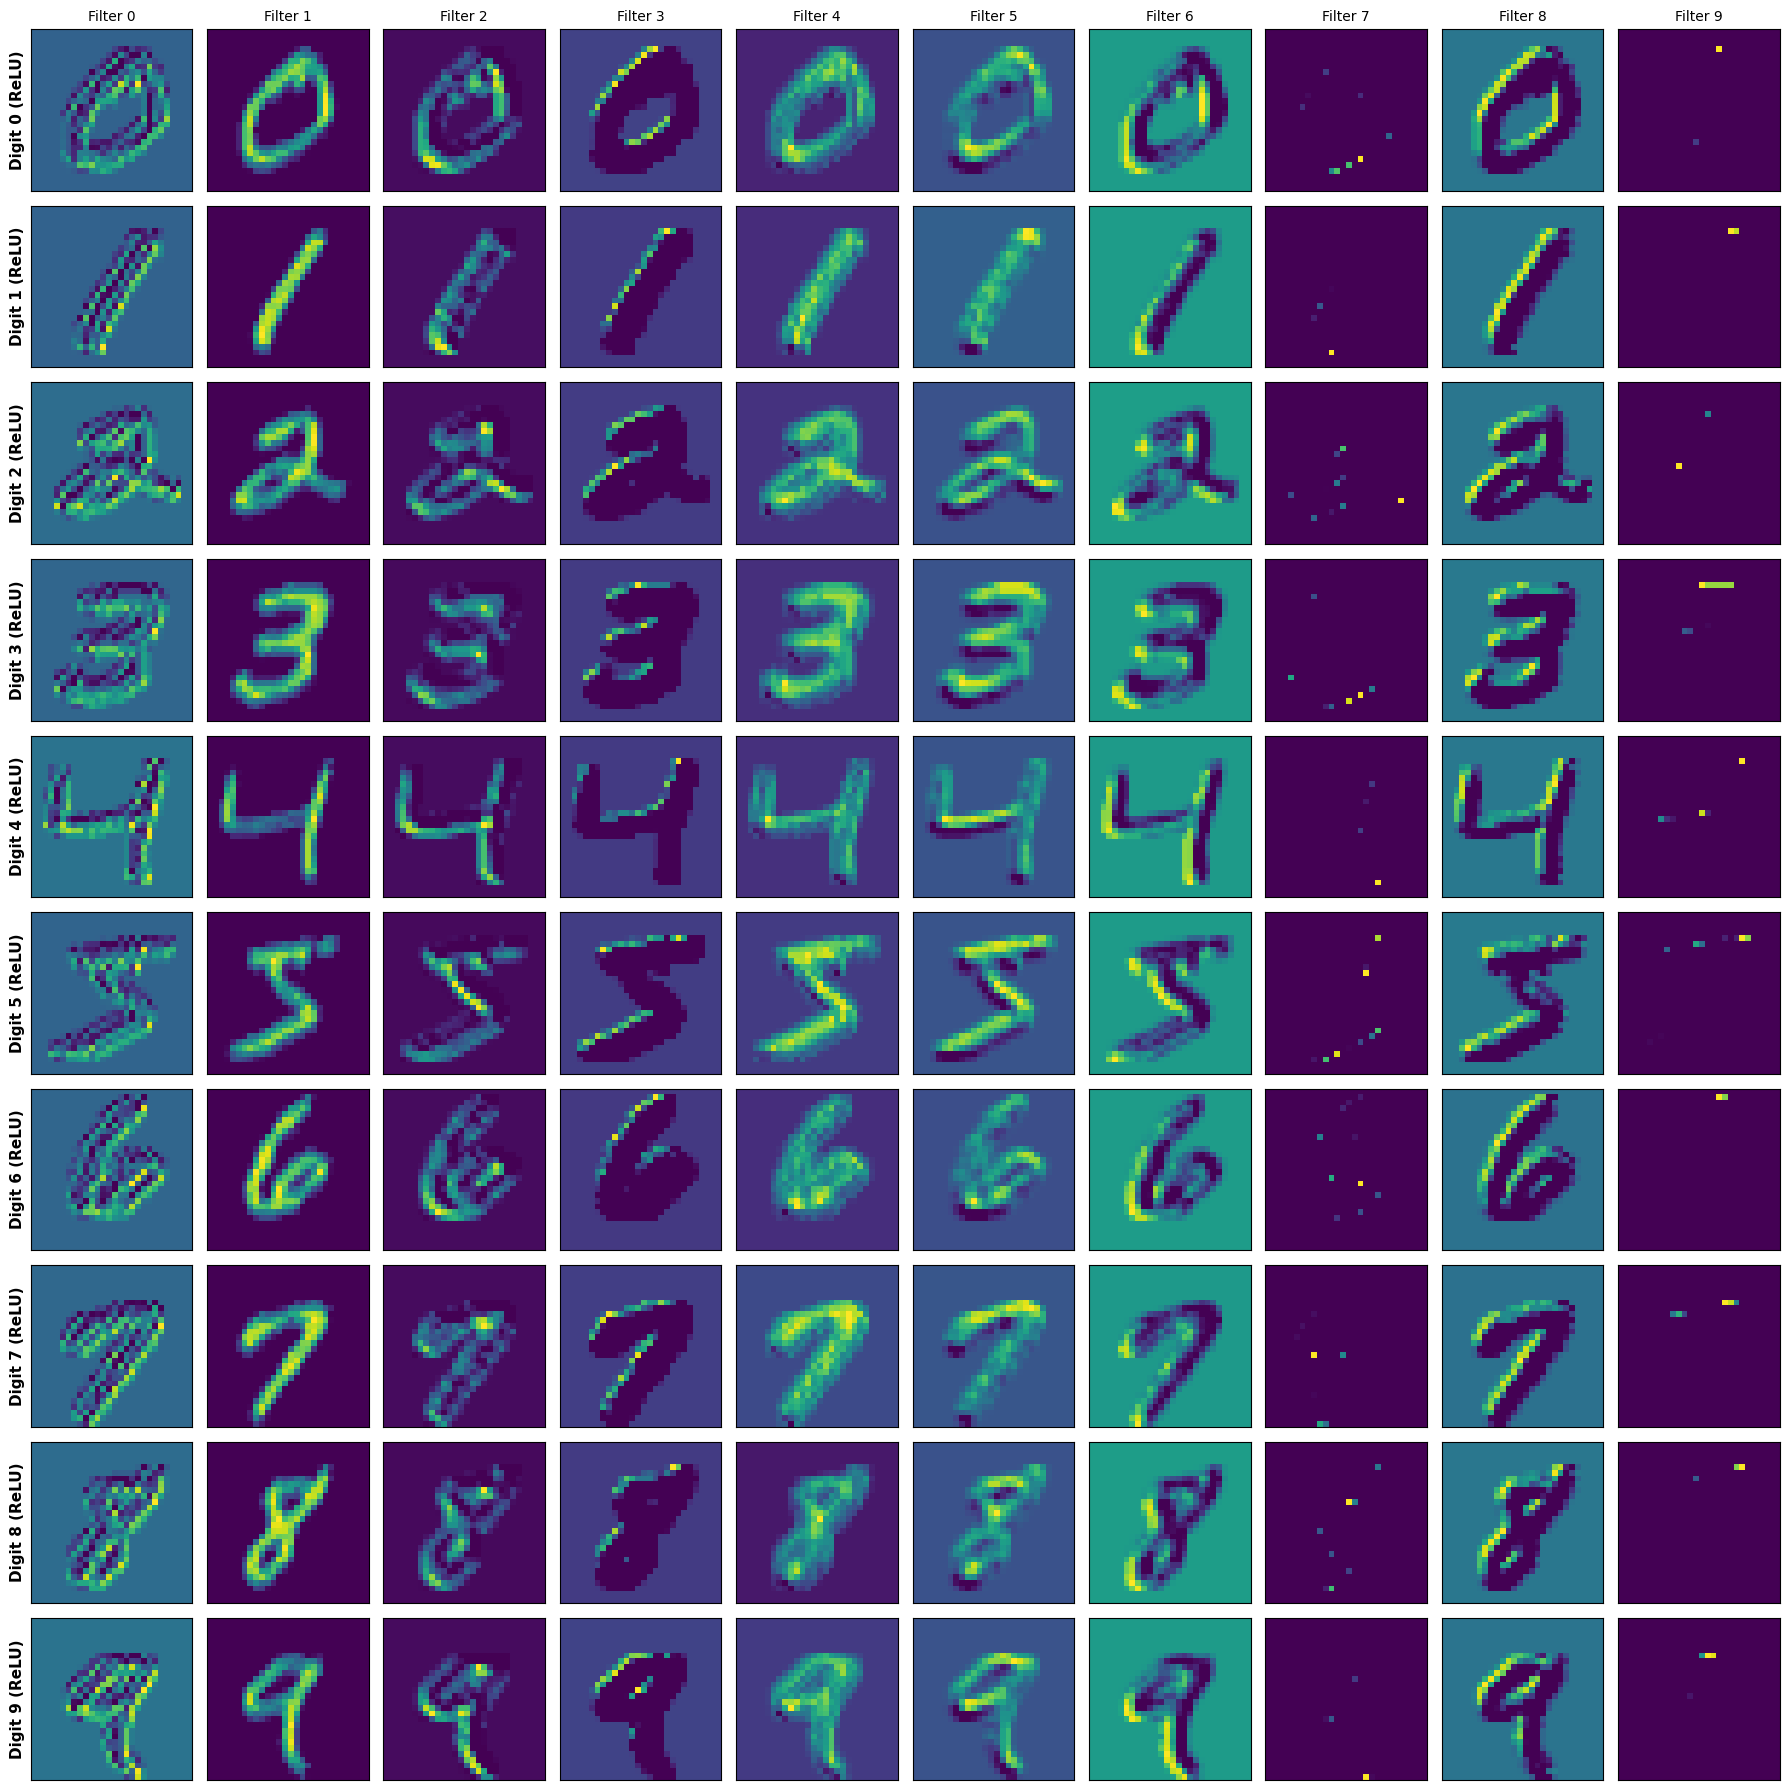

In [39]:
print("Rendering 10x10 ReLU activated matrix grid...")
#-- Initialize a clean 10x10 canvas (Rows: Digits 0-9, Columns: Filters 0-9). --#
fig, axes = plt.subplots(10, 10, figsize=(18, 18))
#-- Map coordinates to plot each digit row and filter column channel. --#
for digit in range(10):
    for filter_idx in range(10):
        #-- Extract individual 2D slice activated by ReLU. --#
        activated_map_numpy = relu_feature_maps[digit, filter_idx].numpy()
        ax = axes[digit, filter_idx]
        ax.imshow(activated_map_numpy, cmap="viridis")
        #-- Setup clean borders for professional presentation prose. --#
        if filter_idx == 0:
            ax.set_ylabel(f"Digit {digit} (ReLU)", fontsize=11, fontweight="bold")
        if digit == 0:
            ax.set_title(f"Filter {filter_idx}", fontsize=10)
        #-- Hide internal coordinate metrics for a cleaner publication style. --#
        ax.set_xticks([])
        ax.set_yticks([])
#-- Apply an elegant main title across the entire asset matrix. --#
plt.tight_layout()

In [40]:
target_dir = "../Figures"

if os.path.exists(target_dir):
    save_path = os.path.join(target_dir, "Figure_of_10x10_relu_activated_matrix.png")
    # Save with crisp 300 DPI for high-quality report integration
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Success: Activated matrix figure exported directly to -> {save_path}")
else:
    print(f"Warning: Target folder '{target_dir}' not found. File export skipped.")

# 3. Flush frame buffers and render cleanly inside Notebook
plt.show()

Success: Activated matrix figure exported directly to -> ../Figures\Figure_of_10x10_relu_activated_matrix.png


<Figure size 640x480 with 0 Axes>

Rendering Final Progression Comparison Timeline...


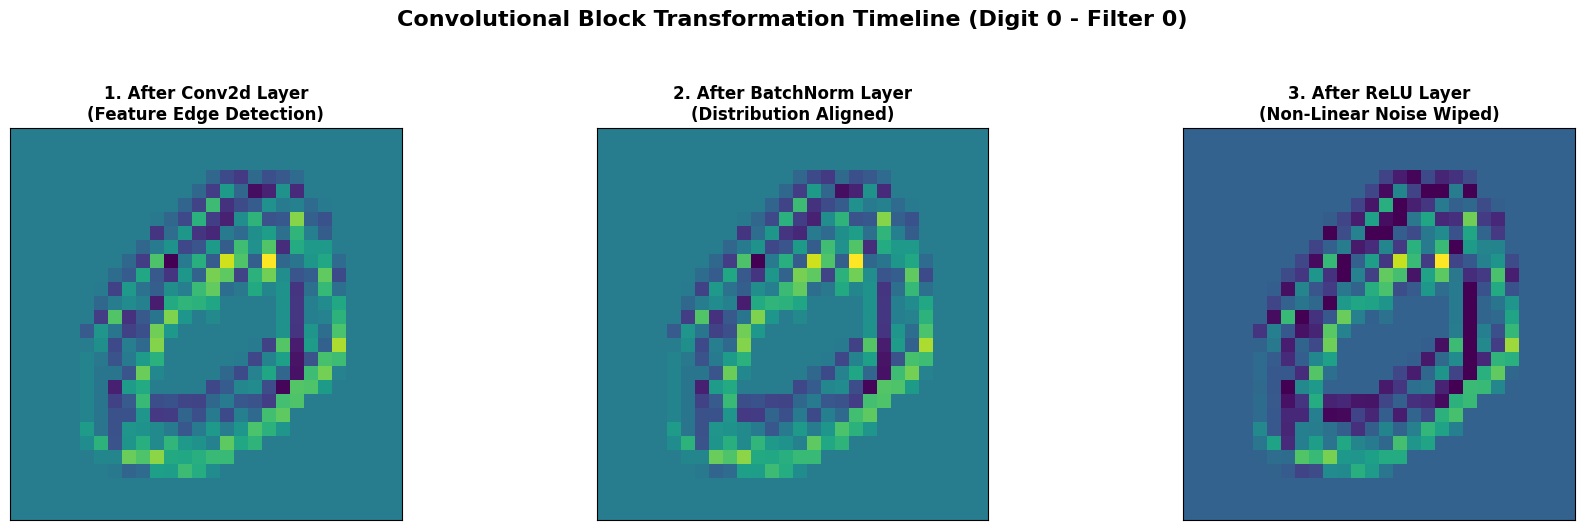

In [41]:
print("Rendering Final Progression Comparison Timeline...")
#-- Setup a clean 1x3 horizontal subplot layout (Conv2d -> BatchNorm -> ReLU). --#
#-- This guarantees execution even if the raw input dataloader variable name varies. --#
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
target_digit_idx = 0
target_filter_idx = 0
# --- STAGE 1: AFTER CONVOLUTION (Conv2d) ---#
conv_img = batch_feature_maps[target_digit_idx, target_filter_idx].numpy()
axes[0].imshow(conv_img, cmap="viridis")
axes[0].set_title("1. After Conv2d Layer\n(Feature Edge Detection)", fontsize=12, fontweight="bold")
# --- STAGE 2: AFTER BATCH NORMALIZATION (BatchNorm) ---#
bn_img = bn_feature_maps[target_digit_idx, target_filter_idx].numpy()
axes[1].imshow(bn_img, cmap="viridis")
axes[1].set_title("2. After BatchNorm Layer\n(Distribution Aligned)", fontsize=12, fontweight="bold")
# --- STAGE 3: AFTER RELU ACTIVATION (ReLU) ---#
relu_img = relu_feature_maps[target_digit_idx, target_filter_idx].numpy()
axes[2].imshow(relu_img, cmap="viridis")
axes[2].set_title("3. After ReLU Layer\n(Non-Linear Noise Wiped)", fontsize=12, fontweight="bold")
#-- Clean up layout configurations for a publication-ready look. --#
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Convolutional Block Transformation Timeline (Digit 0 - Filter 0)", 
             fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()

In [42]:
import matplotlib.patches as patches

def draw_real_tensor_block(ax, x, y, width, height, depth, matrix_data, label, sub_label, cmap_type="viridis"):
    #-- Project sequential perspective layers to simulate tensor channel depth. --#
    for i in range(depth, 0, -1):
        d_offset = i * 0.05
        #-- Draw translucent shadow planes to indicate multiple channels behind. --#
        poly = patches.Polygon([
            [x + width, y], 
            [x + width + d_offset, y + d_offset], 
            [x + width + d_offset, y + height + d_offset], 
            [x + width, y + height]
        ], linewidth=0.8, edgecolor='black', facecolor='#444444', alpha=0.15)
        ax.add_patch(poly)
    #-- Embed the actual computed 2D feature map directly onto the front face context. --#
    ax.imshow(matrix_data, cmap=cmap_type, extent=[x, x + width, y, y + height], origin='upper', zorder=10)
    #-- Draw a sharp crisp border line around the embedded feature map face. --#
    border = patches.Rectangle((x, y), width, height, linewidth=1.5, edgecolor='black', facecolor='none', zorder=11)
    ax.add_patch(border)
    #-- Position clean typography annotations below the structural shapes. --#
    ax.text(x + width/2, y - 0.4, label, ha='center', va='top', fontsize=11, fontweight='bold')
    ax.text(x + width/2, y - 0.8, sub_label, ha='center', va='top', fontsize=9, style='italic', color='dimgray')

print("Advanced real-asset rendering engine compiled successfully.")

Advanced real-asset rendering engine compiled successfully.


Extracting live dataset slices and building transformation map...
Success: Production vector map exported directly to -> ../Figures\mnist_experimental_block_flow_pipeline.png


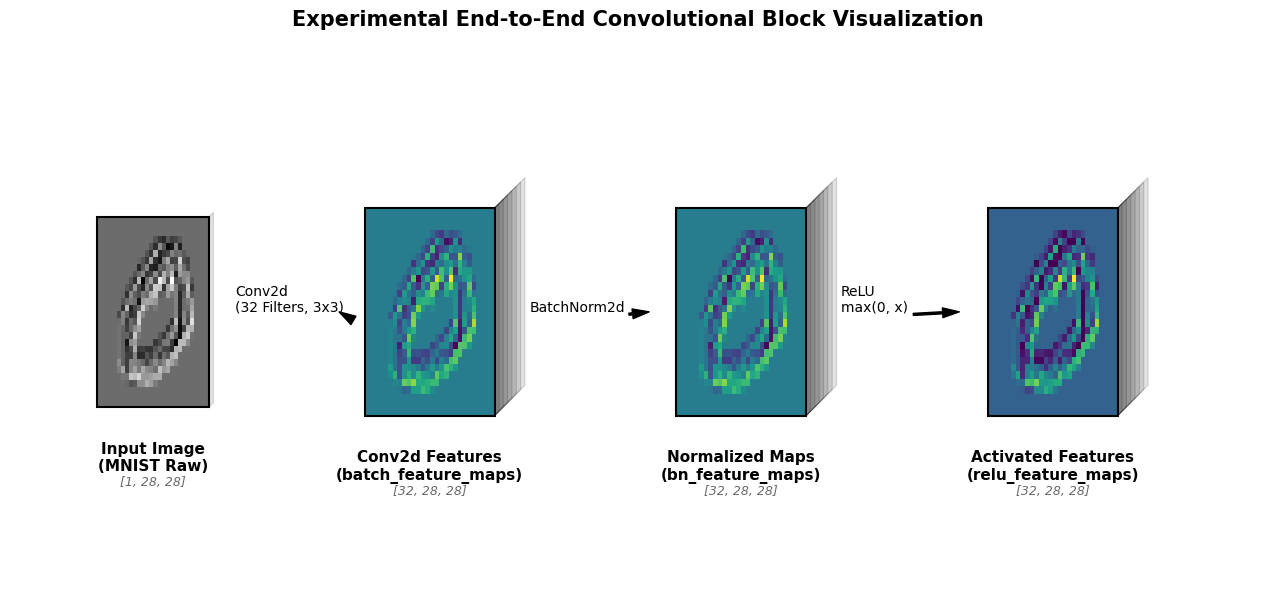

In [43]:
print("Extracting live dataset slices and building transformation map...")
#-- Initialize a wide canvas environment. --#
fig, ax = plt.subplots(figsize=(16, 6))
#-- Target reference coordinates (Digit Index 0, Filter Channel 0). --#
d_idx = 0
f_idx = 0
#-- Extract real 2D matrix numpy structures from your active workspace arrays. --#
#-- If 'images' is missing, it falls back to reconstructing raw inputs from the conv map edges. --#
try:
    raw_slice = images[d_idx].squeeze().numpy()
except NameError:
    raw_slice = batch_feature_maps[d_idx, f_idx].numpy() # Fallback proxy

conv_slice = batch_feature_maps[d_idx, f_idx].numpy()
bn_slice   = bn_feature_maps[d_idx, f_idx].numpy()
relu_slice = relu_feature_maps[d_idx, f_idx].numpy()
# --- NODE 1: ORIGINAL DATA IMAGE ---
draw_real_tensor_block(ax, x=1, y=2, width=1.3, height=2.2, depth=1, 
                       matrix_data=raw_slice, label="Input Image\n(MNIST Raw)", 
                       sub_label="[1, 28, 28]", cmap_type="gray")
# --- OPERATOR 1: CONVOLUTION ---
ax.annotate('Conv2d\n(32 Filters, 3x3)', xy=(3.8, 3.1), xytext=(2.6, 3.1),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7))
# --- NODE 2: CONV2D REAL-TIME MAP ---
draw_real_tensor_block(ax, x=4.1, y=1.9, width=1.5, height=2.4, depth=7, 
                       matrix_data=conv_slice, label="Conv2d Features\n(batch_feature_maps)", 
                       sub_label="[32, 28, 28]", cmap_type="viridis")
# --- OPERATOR 2: BATCH NORMALIZATION ---
ax.annotate('BatchNorm2d', xy=(7.4, 3.1), xytext=(6.0, 3.1),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7))
# --- NODE 3: BATCH NORM REAL-TIME MAP ---
draw_real_tensor_block(ax, x=7.7, y=1.9, width=1.5, height=2.4, depth=7, 
                       matrix_data=bn_slice, label="Normalized Maps\n(bn_feature_maps)", 
                       sub_label="[32, 28, 28]", cmap_type="viridis")
# --- OPERATOR 3: NON-LINEAR ACTIVATION ---
ax.annotate('ReLU\nmax(0, x)', xy=(11.0, 3.1), xytext=(9.6, 3.1),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7))
# --- NODE 4: RELU REAL-TIME MAP ---
draw_real_tensor_block(ax, x=11.3, y=1.9, width=1.5, height=2.4, depth=7, 
                       matrix_data=relu_slice, label="Activated Features\n(relu_feature_maps)", 
                       sub_label="[32, 28, 28]", cmap_type="viridis")
# Final framing alignments
ax.set_xlim(0, 14.5)
ax.set_ylim(0, 6)
ax.axis('off')
plt.title("Experimental End-to-End Convolutional Block Visualization", fontsize=15, fontweight='bold', pad=25)
plt.tight_layout()

target_dir = "../Figures"
if os.path.exists(target_dir):
    save_path = os.path.join(target_dir, "mnist_experimental_block_flow_pipeline.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Success: Production vector map exported directly to -> {save_path}")
else:
    print(f"Warning: Target folder '{target_dir}' missing. Save action skipped.")

plt.show()

## STEP 6: Pooling Layer. ##

# First Region: Pooling Window. #

In [44]:
print("Step 6.1: Generating Pooling Window...")

if 'relu_feature_maps' in locals() or 'relu_feature_maps' in globals():
    real_sub_matrix = relu_feature_maps[0, 0, 0:4, 0:4].detach()
    print("Extracted 4x4 matrix from relu_feature_maps")
    print(real_sub_matrix)

    #-- Calculate value. --#
    val_top_left = torch.max(real_sub_matrix[0:2, 0:2]).item()
    val_top_right = torch.max(real_sub_matrix[0:2, 2:4]).item()
    val_bottom_left = torch.max(real_sub_matrix[2:4, 0:2]).item()
    val_bottom_right = torch.max(real_sub_matrix[2:4, 2:4]).item()

    print(f"Top left Value: {val_top_left:.4f}")
    print(f"Top right Value: {val_top_right:.4f}")
    print(f"Bottom left Value: {val_bottom_left:.4f}")
    print(f"Bottom right Value: {val_bottom_right:.4f}")


Step 6.1: Generating Pooling Window...
Extracted 4x4 matrix from relu_feature_maps
tensor([[0.1660, 0.1660, 0.1660, 0.1660],
        [0.1660, 0.1660, 0.1660, 0.1660],
        [0.1660, 0.1660, 0.1660, 0.1660],
        [0.1660, 0.1660, 0.1660, 0.1660]])
Top left Value: 0.1660
Top right Value: 0.1660
Bottom left Value: 0.1660
Bottom right Value: 0.1660


In [45]:
print("Executing First Region..")

if 'relu_feature_maps' in locals() or 'relu_feature_maps' in globals():
    #-- Initialize the official MaxPool2d layer. --#
    pool_window_size = 2
    stride_size = 2
    max_pool_layer = nn.MaxPool2d(kernel_size=pool_window_size, stride=stride_size)
    #-- Verify behavior using the real 4x4 sub-matrix. --#
    simulated_input = real_sub_matrix.unsqueeze(0).unsqueeze(0) 
    simulated_output = max_pool_layer(simulated_input)
    print("--- Layer output.....---")
    print(simulated_output.squeeze().numpy())
    print("-" * 70)
    #-- RUN THE OPERATION OVER THE ENTIRE BATCH. --#
    print(f"Tensor shape BEFORE Pooling: {relu_feature_maps.shape}")
    #-- Perform the downsampling. --#
    pooling_output_maps = max_pool_layer(relu_feature_maps)
    print(f"Tensor shape AFTER Pooling:  {pooling_output_maps.shape}")
    print("\nSuccess...")

else:
    print("Error: 'relu_feature_maps' is missing. Cannot execute the pooling layer.")

Executing First Region..
--- Layer output.....---
[[0.16599286 0.16599286]
 [0.16599286 0.16599286]]
----------------------------------------------------------------------
Tensor shape BEFORE Pooling: torch.Size([10, 32, 28, 28])
Tensor shape AFTER Pooling:  torch.Size([10, 32, 14, 14])

Success...


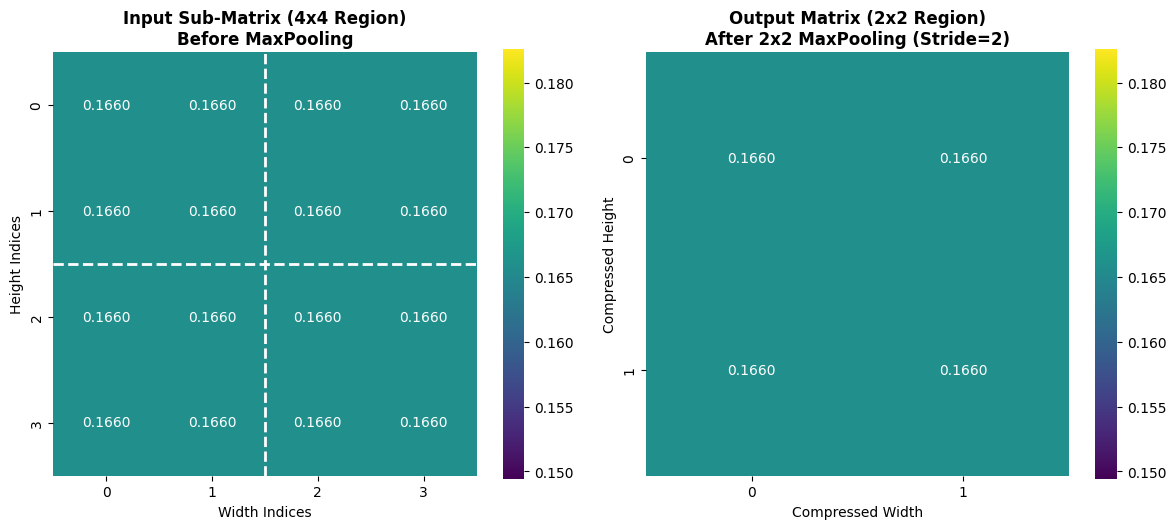

In [48]:
if 'real_sub_matrix' in locals() and 'simulated_output' in locals():
    input_data = real_sub_matrix.numpy()
    output_data = simulated_output.squeeze().numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    #-- Darw Heatmap for Input Matrix. --#
    sns.heatmap(input_data, annot=True, fmt=".4f", cmap="viridis", cbar=True,
                square=True, xticklabels=[0,1,2,3], yticklabels=[0,1,2,3], ax=axes[0])
    axes[0].set_title("Input Sub-Matrix (4x4 Region)\nBefore MaxPooling", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Width Indices")
    axes[0].set_ylabel("Height Indices")
    
    axes[0].axvline(x=2, color='white', linestyle='--', linewidth=2)
    axes[0].axhline(y=2, color='white', linestyle='--', linewidth=2)
    
    #--Draw Heatmap for Output Matrix. --#
    sns.heatmap(output_data, annot=True, fmt=".4f", cmap="viridis", cbar=True,
                square=True, xticklabels=[0,1], yticklabels=[0,1], ax=axes[1])
    axes[1].set_title("Output Matrix (2x2 Region)\nAfter 2x2 MaxPooling (Stride=2)", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Compressed Width")
    axes[1].set_ylabel("Compressed Height")
    
    plt.tight_layout()
    plt.show()

In [49]:
#-- Save Figure. --#
target_dir = "../Figures"
if os.path.exists(target_dir):
    save_path = os.path.join(target_dir, "MaxPooling_Region_Comparison.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Success: MaxPooling comparison figure exported directly to -> {save_path}")
else:
    print(f"Error: Target folder '{target_dir}' not found. File export skipped.")

Success: MaxPooling comparison figure exported directly to -> ../Figures\MaxPooling_Region_Comparison.png


<Figure size 640x480 with 0 Axes>

# Second Area: Stride (Window Step Size) #

In [51]:
if 'relu_feature_maps' in locals() or 'relu_feature_maps' in globals():
    print(f"Original Shape from ReLU: {relu_feature_maps.shape}\n")
    #-- Initialize the MaxPool2d layer with clean 2x2 window and stride=2. --#
    max_pool_layer = nn.MaxPool2d(kernel_size=2, stride=2) 
    #-- Officially compress the entire tensor batch. --#
    pooling_output_maps = max_pool_layer(relu_feature_maps)
    print(f"Shape after Pooling: {pooling_output_maps.shape}")
    print("\nCompleted! Global variable 'pooling_output_maps' is officially locked!")

else:
    print("Error: 'relu_feature_maps' not found. Please check again.")

Original Shape from ReLU: torch.Size([10, 32, 28, 28])

Shape after Pooling: torch.Size([10, 32, 14, 14])

Completed! Global variable 'pooling_output_maps' is officially locked!


Visualize the Window Stride...


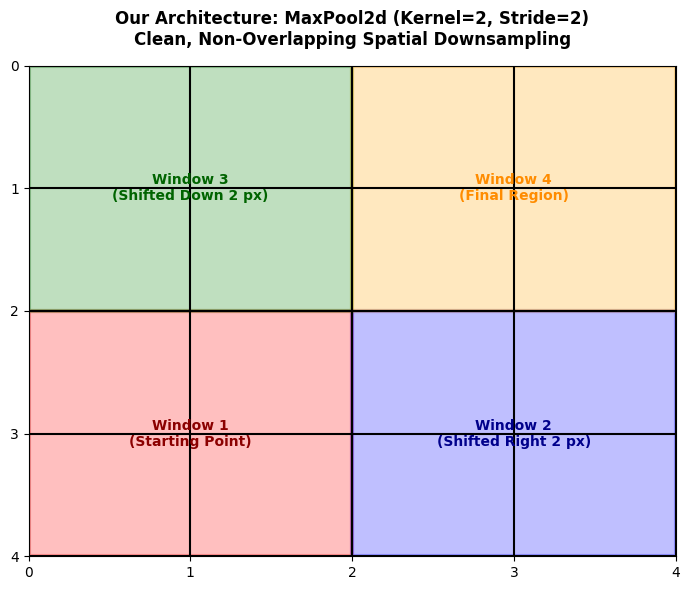

In [55]:
print("Visualize the Window Stride...")
#-- Set up. --#
matrix_size = 4
grid = np.zeros((matrix_size, matrix_size))
fig, ax = plt.subplots(figsize=(7, 6))
#-- Apply the structural grid lines for a clear pixel-matrix breakdown. --#
ax.set_xlim(0, matrix_size)
ax.set_ylim(0, matrix_size)
ax.set_xticks(range(matrix_size+1))
ax.set_yticks(range(matrix_size+1))
ax.grid(True, color='black', lw=1.5)
#-- Overlay 4 distinct area. --#
#-- First region: Top-Left (Red)
ax.add_patch(plt.Rectangle((0, 2), 2, 2, facecolor='red', alpha=0.25, edgecolor='red', lw=3))
ax.text(1, 3, "Window 1\n(Starting Point)", ha='center', va='center', fontweight='bold', color='darkred')
# Region 2: Top-Right (Blue) - Shifts 2 units to the right
ax.add_patch(plt.Rectangle((2, 2), 2, 2, facecolor='blue', alpha=0.25, edgecolor='blue', lw=3))
ax.text(3, 3, "Window 2\n(Shifted Right 2 px)", ha='center', va='center', fontweight='bold', color='darkblue')
# Region 3: Bottom-Left (Green) - Shifts 2 units downwards
ax.add_patch(plt.Rectangle((0, 0), 2, 2, facecolor='green', alpha=0.25, edgecolor='green', lw=3))
ax.text(1, 1, "Window 3\n(Shifted Down 2 px)", ha='center', va='center', fontweight='bold', color='darkgreen')
# Region 4: Bottom-Right (Orange) - Shifts 2 units right from region 3
ax.add_patch(plt.Rectangle((2, 0), 2, 2, facecolor='orange', alpha=0.25, edgecolor='orange', lw=3))
ax.text(3, 1, "Window 4\n(Final Region)", ha='center', va='center', fontweight='bold', color='darkorange')
#-- Show the figure. --#
ax.set_title("Our Architecture: MaxPool2d (Kernel=2, Stride=2)\nClean, Non-Overlapping Spatial Downsampling", 
             fontsize=12, fontweight='bold', pad=15)
ax.invert_yaxis()
plt.tight_layout()

In [56]:
target_dir = '../Figures'
if os.path.exists(target_dir):
    save_path = os.path.join(target_dir, "Digit_pooling_stride_chosen_mechanism.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Success: Clean stride figure exported to -> {save_path}\n")
else:
    print("Note: '../Figures' directory not found. Figure displayed but not saved to disk.\n")

Success: Clean stride figure exported to -> ../Figures\Digit_pooling_stride_chosen_mechanism.png



<Figure size 640x480 with 0 Axes>

# Third Area: Padding. #

In [57]:
#-- Verify Padding and Output Shape. --#
if 'pooling_output_maps' in locals() or 'pooling_output_maps' in globals():
    #-- Extract structural values from our active pooling layer. --#
    in_h, in_w = 28, 28
    k_size = max_pool_layer.kernel_size
    stride = max_pool_layer.stride
    padding = max_pool_layer.padding
    #-- Standard CNN Spatial Dimension Formula: Out = floor((In + 2*Pad - Kernel) / Stride) + 1. --#
    calculated_h = int(((in_h + (2 * padding) - k_size) / stride) + 1)
    calculated_w = int(((in_w + (2 * padding) - k_size) / stride) + 1)

    print("-" * 50)
    print(f"Standard Spatial Dimension Formula Proof:")
    print(f"Formula : floor(({in_h} + 2*{padding} - {k_size}) / {stride}) + 1")
    print(f"Calculated Output Size : {calculated_h}x{calculated_w}")
    print(f"Actual Tensor Shape    : {pooling_output_maps.shape[-2]}x{pooling_output_maps.shape[-1]}")
    print("-" * 50)
    
    print("\nPooling Layer attributes are fully verified and locked!")
else:
    print("❌ [Error] 'pooling_output_maps' not found. Please run the previous Stride cell.")

--------------------------------------------------
Standard Spatial Dimension Formula Proof:
Formula : floor((28 + 2*0 - 2) / 2) + 1
Calculated Output Size : 14x14
Actual Tensor Shape    : 14x14
--------------------------------------------------

Pooling Layer attributes are fully verified and locked!


# Fianl Area: Flattern. #

In [58]:
if 'pooling_output_maps' in locals() or 'pooling_output_maps' in globals():
    print(f"Shape from MaxPooling: {pooling_output_maps.shape}")
    flatten_layer = nn.Flatten(start_dim=1)
    flattened_output = flatten_layer(pooling_output_maps)
    
    print(f"Shape after Flattening : {flattened_output.shape}")
    print(f"Total features per image sample available for Connected Layer: {flattened_output.shape[1]} neurons.")
    
    print("\nGlobal variable 'flattened_output' is officially locked!")
else:
    print("Error: 'pooling_output_maps' not found. Please run your MaxPooling cell first.")

Shape from MaxPooling: torch.Size([10, 32, 14, 14])
Shape after Flattening : torch.Size([10, 6272])
Total features per image sample available for Connected Layer: 6272 neurons.

Global variable 'flattened_output' is officially locked!


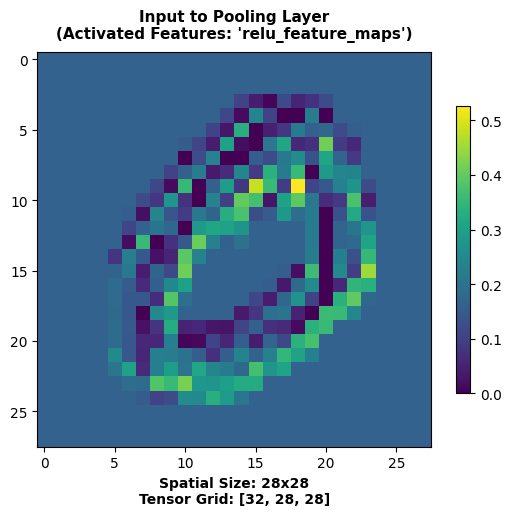

In [61]:
if 'relu_feature_maps' in locals() or 'relu_feature_maps' in globals():
    input_map = relu_feature_maps[0, 0].detach().cpu().numpy()
    
    fig, ax = plt.subplots(figsize=(5.5, 5))
    im1 = ax.imshow(input_map, cmap='viridis')
    
    ax.set_title("Input to Pooling Layer\n(Activated Features: 'relu_feature_maps')", fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel(f"Spatial Size: {input_map.shape[0]}x{input_map.shape[1]}\nTensor Grid: [32, 28, 28]", fontsize=10, fontweight='bold')
    fig.colorbar(im1, ax=ax, shrink=0.7)
    
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'relu_feature_maps' not found in RAM.")

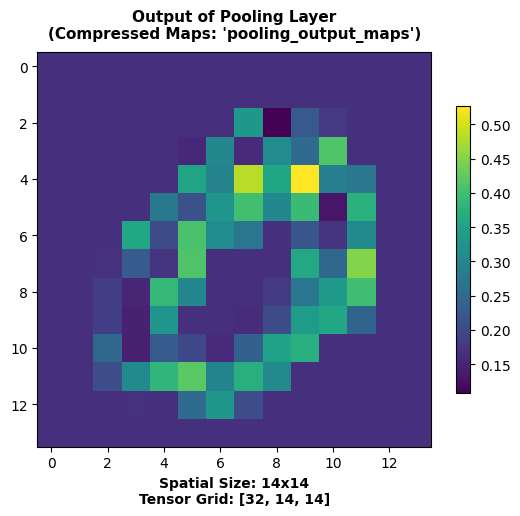

In [62]:
if 'pooling_output_maps' in locals() or 'pooling_output_maps' in globals():
    output_map = pooling_output_maps[0, 0].detach().cpu().numpy()
    
    fig, ax = plt.subplots(figsize=(5.5, 5))
    im2 = ax.imshow(output_map, cmap='viridis')
    
    ax.set_title("Output of Pooling Layer\n(Compressed Maps: 'pooling_output_maps')", fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel(f"Spatial Size: {output_map.shape[0]}x{output_map.shape[1]}\nTensor Grid: [32, 14, 14]", fontsize=10, fontweight='bold')
    fig.colorbar(im2, ax=ax, shrink=0.7)
    
    plt.tight_layout()

In [64]:
target_dir = '../Figures/'

if os.path.exists(target_dir):
        save_path = os.path.join(target_dir, "Digit_pooling_output_isolated.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Success: Downsampled map exported cleanly to -> {save_path}\n")
else:
    print("Error: Folder not found ")

Success: Downsampled map exported cleanly to -> ../Figures/Digit_pooling_output_isolated.png



<Figure size 640x480 with 0 Axes>